# General Assay Results Plotting

This notebook generates a high-resolution line-and-scatter plot for various biochemical assays (e.g., Inhibition, Activity, Concentration). 

### Features:
- **Dynamic Column Detection**: Automatically identifies Concentration and Standard columns.
- **Multi-Sample Support**: Plots any number of additional samples present in the CSV.
- **Professional Styling**: Uses a high-quality scientific plotting style with a safe color palette (no red, maroon, or black).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

### 1. Load the Data
Ensure your CSV file is in the same folder as this notebook. Change the filename below if needed.

In [2]:
# Path to your CSV file
csv_path = 'Job.csv'

try:
    df = pd.read_csv(csv_path)
    
    # CLEANING: Remove any leading/trailing whitespace from column names to prevent KeyErrors
    df.columns = df.columns.str.strip()
    
    print(f"Successfully loaded: {csv_path}")
    print("Detected Columns:", df.columns.tolist())
    display(df.head())
    
except FileNotFoundError:
    print(f"Error: '{csv_path}' not found. Please ensure the file is in this directory.")

Successfully loaded: Job.csv
Detected Columns: ['Concentration (mM)', 'FA', 'FA-1', 'FA-2', 'FA-3', 'FA-4', 'FA-5']


,Concentration (mM),FA,FA-1,FA-2,FA-3,FA-4,FA-5
0,0.2,56.09,2.62,5.62,6.66,16.60,0.56
1,0.4,66.13,6.19,7.97,7.31,19.32,2.62
2,0.6,72.04,10.13,19.04,13.13,21.85,10.03
3,0.8,80.01,11.25,21.10,21.20,23.54,15.57
4,1.0,80.39,13.88,29.83,24.85,31.05,15.47


### 2. Generate and Save Plot
The following code replicates a high-quality scientific plotting style with dynamic labeling.

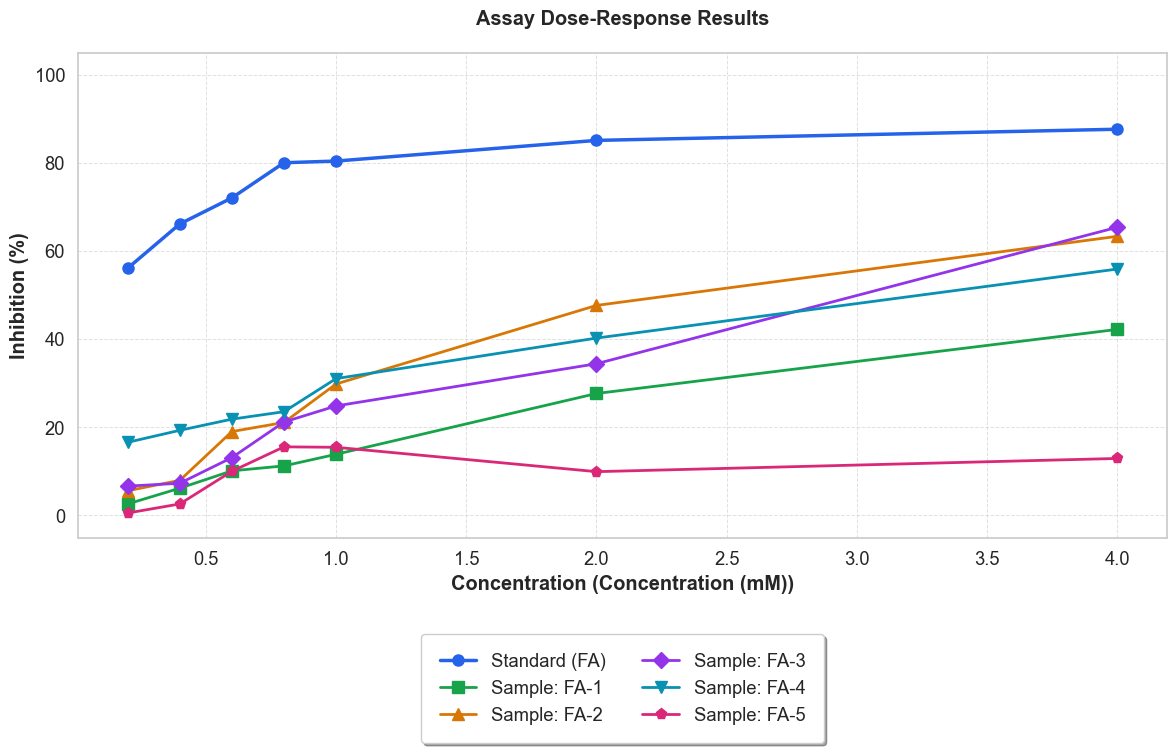

Plot successfully saved to: assay_plot.png
Mapped Standard to: FA
Mapped Samples to: FA-1, FA-2, FA-3, FA-4, FA-5


In [3]:
try:
    # Identify columns dynamically
    # First column is usually concentration, but we'll try to find 'Mass (ug)'
    col_x = 'Mass (ug)' if 'Mass (ug)' in df.columns else df.columns[0]
    
    # Identify standard and samples
    col_std = None
    sample_cols = []
    
    for col in df.columns:
        if col == col_x:
            continue
        if 'std' in col.lower() or 'standard' in col.lower() or 'inhibition%' in col.lower() and col_std is None:
            col_std = col
        else:
            sample_cols.append(col)

    # If col_std was not found, take the first non-X column as standard if there are others
    if col_std is None and len(df.columns) > 1:
        col_std = [c for c in df.columns if c != col_x][0]
        sample_cols = [c for c in df.columns if c != col_x and c != col_std]

    # Professional color palette (Avoiding maroon, red, and black)
    colors = ['#2563eb', '#16a34a', '#d97706', '#9333ea', '#0891b2', '#db2777', '#4f46e5', '#ca8a04']
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']

    # Set the style
    sns.set_theme(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(12, 8))

    # Plot Standard
    if col_std:
        plt.plot(df[col_x], df[col_std], 
                 label=f'Standard ({col_std})', color=colors[0], marker=markers[0], 
                 linestyle='-', linewidth=2.5, markersize=8)

    # Plot Samples
    for i, col in enumerate(sample_cols):
        color_idx = (i + 1) % len(colors)
        marker_idx = (i + 1) % len(markers)
        plt.plot(df[col_x], df[col], 
                 label=f'Sample: {col}', color=colors[color_idx], marker=markers[marker_idx], 
                 linestyle='-', linewidth=2, markersize=8)

    # Axis labels and titles (Generalized)
    plt.xlabel(f'Concentration ({col_x})', fontweight='bold')
    plt.ylabel('Inhibition (%)', fontweight='bold')
    plt.title('Assay Dose-Response Results', fontweight='bold', pad=20)

    # Customizing the layout and grid
    plt.gca().spines['top'].set_visible(True)
    plt.gca().spines['right'].set_visible(True)
    plt.grid(True, which='both', linestyle='--', alpha=0.6, linewidth=0.7)
    # Legend placement (Bottom Center to avoid overlap with curves)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), 
               frameon=True, shadow=True, borderpad=1, ncol=2)
    plt.ylim(-5, 105)

    # Save and Show
    output_path = 'assay_plot.png'
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Plot successfully saved to: {output_path}")
    print(f"Mapped Standard to: {col_std}")
    print(f"Mapped Samples to: {', '.join(sample_cols)}")

except (KeyError, NameError) as e:
    if 'df' not in locals():
        print("Error: Dataframe not loaded. Please run the data loading cell first.")
    else:
        print(f"Error: {e}")
        print("Available columns are:", df.columns.tolist())
except Exception as e:
    print(f"An unexpected error occurred: {e}")